In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from neuralop.losses.differentiation import FiniteDiff

device = torch.device("cuda") # Use GPU 

In [ ]:
import torch.nn.functional as F

# Gaussian Smoothing 함수 정의
def smooth_initial_condition(tensor, sigma=2):
    # 단순 가우시안 커널 적용 (5x5)
    kernel_size = 5
    kernel = torch.ones((1, 1, kernel_size, kernel_size)).to(tensor.device) / (kernel_size**2)
    # [1, 128, 128] -> [1, 1, 128, 128]로 차원 맞추고 필터링
    smoothed = F.conv2d(tensor.unsqueeze(0), kernel, padding=kernel_size//2).squeeze(0) # unsqueeze는 차원을 늘려주고 squeeze는 차원을 줄여줌 ()안의 숫자 번째 차원을 줄임. 
    return smoothed


def generate_burgers_data(n_samples, nt, dt, nu, fd):
    all_inputs = []
    all_outputs = []

    for i in range(n_samples):
        # 1. 무작위 초기 조건 생성 (여기가 중요!)
        # 단순 상수가 아니라 랜덤한 파형을 주어야 모델이 공부할 게 생깁니다.
        u = torch.randn(1, 128, 128).cuda() # 평균 0 표준편차 1 격자개수 128*128
        v = torch.randn(1, 128, 128).cuda()
        u = smooth_initial_condition(u)
        v = smooth_initial_condition(v)
        # t=0 상태 저장 (Input)
        initial_state = torch.cat([u, v], dim=0) # [2, 128, 128]
        all_inputs.append(initial_state.clone())

        # 2. 시뮬레이션 루프 (nt 단계 진행)
        for _ in range(nt):
            u_x, u_y = fd.dx(u), fd.dy(u)
            v_x, v_y = fd.dx(v), fd.dy(v)
            u_xx, u_yy = fd.dx(u_x), fd.dy(u_y)
            v_xx, v_yy = fd.dx(v_x), fd.dy(v_y)

            u = u + dt * (-u * u_x - v * u_y + nu * (u_xx + u_yy))
            v = v + dt * (-u * v_x - v * v_y + nu * (v_xx + v_yy))

        # boundary condition
        u[:, 0, :] = 0  # 테두리 0으로 덮어쓰기
        u[:, -1, :] = 0
        u[:, :, 0] = 0
        u[:, :, -1] = 0

        v[:, 0, :] = 0  # 테두리 0으로 덮어쓰기
        v[:, -1, :] = 0
        v[:, :, 0] = 0
        v[:, :, -1] = 0


        # 3. 최종 상태 저장 (Output)
        final_state = torch.cat([u, v], dim=0) # [2, 128, 128]
        all_outputs.append(final_state.clone())

    # 4. 전체 데이터를 하나의 텐서로 병합
    x_train = torch.stack(all_inputs)  # [n_samples, 2, 128, 128]
    y_train = torch.stack(all_outputs) # [n_samples, 2, 128, 128]
    
    return x_train, y_train

Lx, Ly = 2.0, 2.0 # Domain lengths
nx, ny = 64, 64 # grid resolution
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)
fd = FiniteDiff(dim=2, h=(dx, dy)) # 2차원에서 dx, dy 간격으로 finite difference 계산

# 실행 예시
x_data, y_data = generate_burgers_data(n_samples=500, nt=100, dt=0.001, nu=0.01, fd=fd)

In [19]:
x_data.shape

torch.Size([500, 2, 128, 128])

In [14]:
from neuralop.models import FNO

model = FNO(
    n_modes=(16, 16),      # 주파수 공간에서 필터링할 모드 수
    hidden_channels=64,    # 모델의 은닉층 너비
    in_channels=2,         # 입력 채널: t=0일 때의 (u, v)
    out_channels=2,        # 출력 채널: t=T일 때의 (u, v)
    factorization='tucker' # 연산 효율을 위한 텐서 분해 방식
)

In [15]:
# 2. 데이터셋 분할 (학습용 400개, 검증용 100개)
from torch.utils.data import DataLoader, TensorDataset

train_db = TensorDataset(x_data[:400], y_data[:400])
test_db = TensorDataset(x_data[400:], y_data[400:])

train_loader = DataLoader(train_db, batch_size=20, shuffle=True)
test_loader = DataLoader(test_db, batch_size=20, shuffle=False)

In [16]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100) # 학습률 자동 조절
criterion = torch.nn.MSELoss() # 일단 가장 기본인 MSE 사용

In [17]:
device = torch.device('cuda')
model.to(device)

epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    scheduler.step()
    if epoch % 1 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.6f}")

Epoch [1/100], Loss: 0.019992
Epoch [2/100], Loss: 0.008751
Epoch [3/100], Loss: 0.003712
Epoch [4/100], Loss: 0.003240
Epoch [5/100], Loss: 0.002921
Epoch [6/100], Loss: 0.002624
Epoch [7/100], Loss: 0.002488
Epoch [8/100], Loss: 0.002432
Epoch [9/100], Loss: 0.002428
Epoch [10/100], Loss: 0.002398
Epoch [11/100], Loss: 0.002399
Epoch [12/100], Loss: 0.002407
Epoch [13/100], Loss: 0.002357
Epoch [14/100], Loss: 0.002349
Epoch [15/100], Loss: 0.002359
Epoch [16/100], Loss: 0.002354
Epoch [17/100], Loss: 0.002343
Epoch [18/100], Loss: 0.002341
Epoch [19/100], Loss: 0.002351
Epoch [20/100], Loss: 0.002341
Epoch [21/100], Loss: 0.002332
Epoch [22/100], Loss: 0.002338
Epoch [23/100], Loss: 0.002332
Epoch [24/100], Loss: 0.002336
Epoch [25/100], Loss: 0.002329
Epoch [26/100], Loss: 0.002328
Epoch [27/100], Loss: 0.002332
Epoch [28/100], Loss: 0.002348
Epoch [29/100], Loss: 0.002329
Epoch [30/100], Loss: 0.002329
Epoch [31/100], Loss: 0.002324
Epoch [32/100], Loss: 0.002314
Epoch [33/100], L

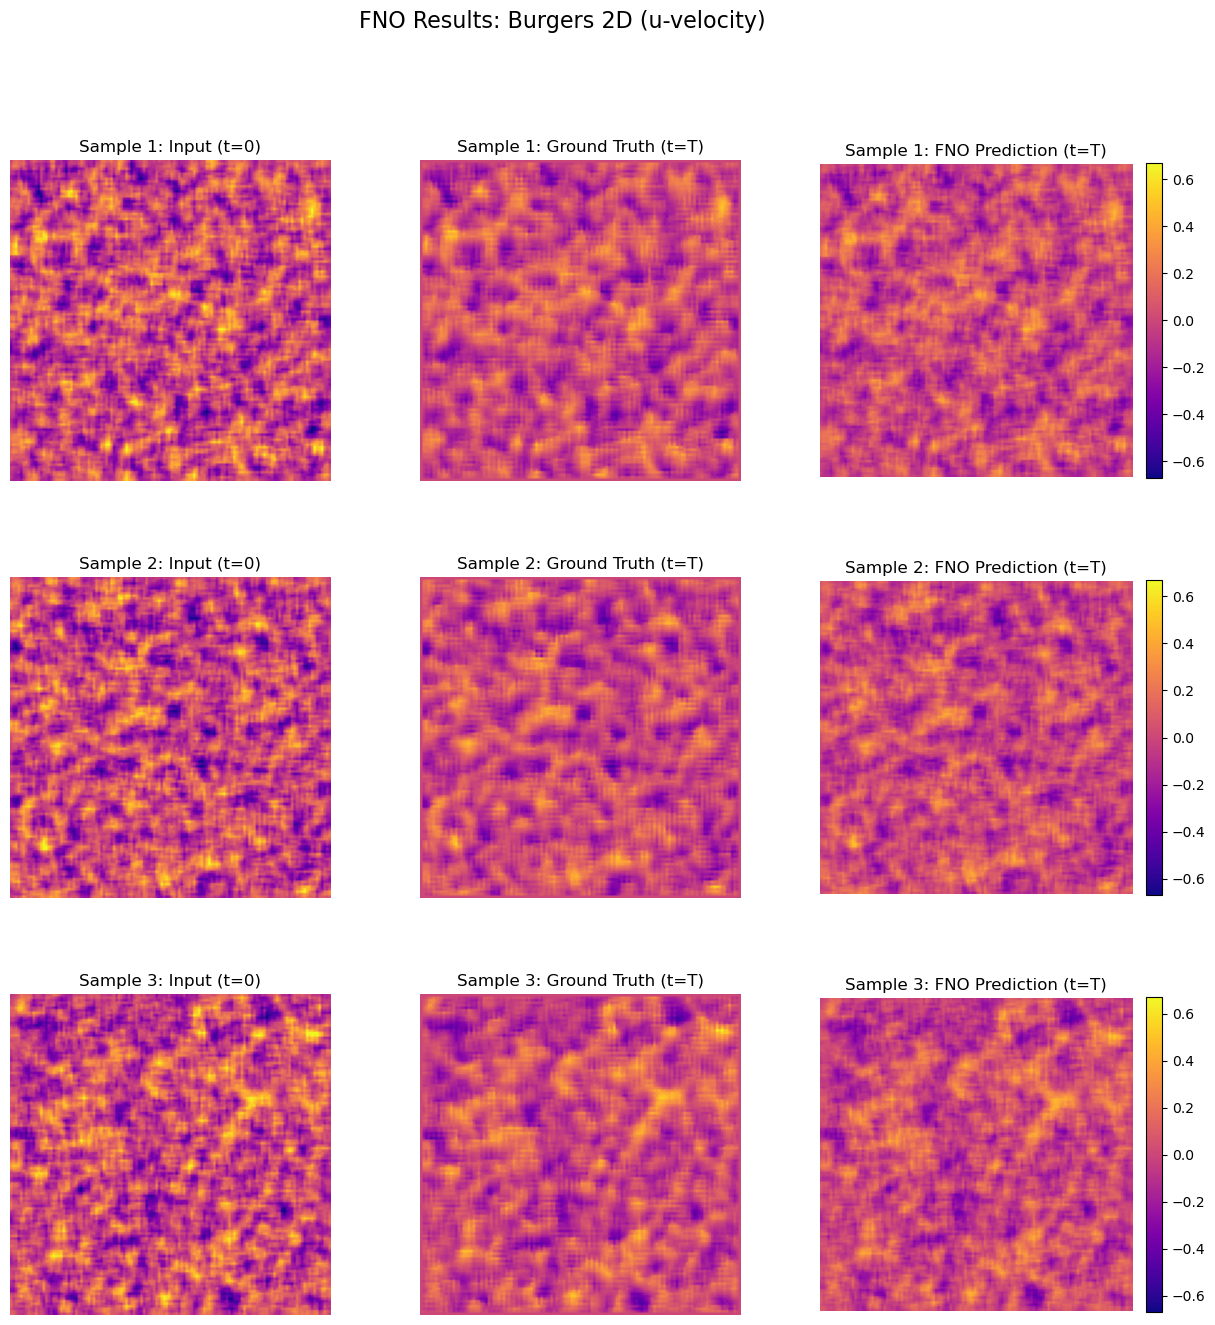

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_fno_results(model, test_loader, device, n_samples=3):
    """
    학습된 FNO 모델의 예측 결과를 실제 정답과 비교하여 시각화합니다.
    
    Args:
        model: 학습된 FNO 모델
        test_loader: 검증용 데이터 로더 (x: t=0, y: t=T)
        device: GPU/CPU 장치
        n_samples: 시각화할 샘플 개수
    """
    model.eval() # 평가 모드 전환
    
    # 테스트 로더에서 샘플 가져오기
    # x: [Batch, 2, 128, 128] @ t=0, y: [Batch, 2, 128, 128] @ t=T
    x_test, y_test = next(iter(test_loader))
    x_test, y_test = x_test.to(device), y_test.to(device)
    
    # FNO 모델 예측
    with torch.no_grad():
        pred_y = model(x_test)
        
    # 데이터를 CPU로 가져오고 Numpy로 변환 (시각화용)
    x_test = x_test.cpu().numpy() # [Batch, 2, 128, 128]
    y_test = y_test.cpu().numpy()
    pred_y = pred_y.cpu().numpy()
    
    # 그림 그리기 설정 (u 성분만 시각화 예시, v도 가능)
    # n_samples만큼 행(Row)을 만들고, 3개의 열(Column)을 만듭니다.
    fig, axs = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    
    # 색상 범위 통일을 위한 최솟값/최댓값 계산
    vmax = np.max(np.abs(y_test[:n_samples, 0])) # u 성분의 절대 최댓값
    vmin = -vmax

    for i in range(n_samples):
        # 1. Input (t=0, u 성분)
        im0 = axs[i, 0].imshow(x_test[i, 0], cmap='plasma', origin='lower', vmin=vmin, vmax=vmax)
        axs[i, 0].set_title(f'Sample {i+1}: Input (t=0)')
        axs[i, 0].axis('off')
        
        # 2. Ground Truth (t=T, u 성분) - 수치 해석 정답
        im1 = axs[i, 1].imshow(y_test[i, 0], cmap='plasma', origin='lower', vmin=vmin, vmax=vmax)
        axs[i, 1].set_title(f'Sample {i+1}: Ground Truth (t=T)')
        axs[i, 1].axis('off')
        
        # 3. FNO Prediction (t=T, u 성분) - AI 예측값
        im2 = axs[i, 2].imshow(pred_y[i, 0], cmap='plasma', origin='lower', vmin=vmin, vmax=vmax)
        axs[i, 2].set_title(f'Sample {i+1}: FNO Prediction (t=T)')
        axs[i, 2].axis('off')

        fig.colorbar(im2, ax=axs[i, 2], orientation='vertical', fraction=0.046, pad=0.04)

    plt.suptitle('FNO Results: Burgers 2D (u-velocity)', fontsize=16)
    plt.show()

# --- 실행 방법 ---
# 학습 루프가 끝난 후 아래 한 줄을 실행하세요.
visualize_fno_results(model, test_loader, device, n_samples=3)